 # 06 — Comprehensive System Evaluation 📊

 This notebook evaluates both core components of the Neural Career Advisor:
 1. **RAG Pipeline Evaluation:** Measures Retrieval Hit Rate, Latency, and Generation Faithfulness (Anti-Hallucination checks).
 2. **Machine Learning Model Evaluation:** Measures MAE, RMSE, and $R^2$ on the held-out 2025 dataset, complete with diagnostic plots.

 *This notebook serves as the final validation step before deployment.*

In [1]:
import sys
import os
import time
import re
from pathlib import Path

# Connect to shared configuration
for _candidate in [Path(".."), Path("."), Path("../..")]:
    if (_candidate / "config.py").exists():
        sys.path.insert(0, str(_candidate.resolve()))
        break
import config as cfg

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
try:
    import salary_utils
except ImportError:
    print("Warning: salary_utils.py not found. ML evaluation might fail if pipeline needs it.")

# RAG Evaluation
import faiss
import ollama
from sentence_transformers import SentenceTransformer

# Plot styling
sns.set_theme(style="whitegrid")
DATA_DIR = "data"

 ## 1. RAG System Evaluation 🧠
 Evaluating a RAG (Retrieval-Augmented Generation) system locally.
 We use a synthetic test set of questions mapped to expected fact categories to calculate **Retrieval Hit Rate**.
 We also measure **Faithfulness** by verifying that all numbers output by the LLM actually exist in the retrieved context.

In [2]:
print("Loading RAG components for evaluation...")

facts_df = pd.read_csv(f"{DATA_DIR}/facts.csv")
index = faiss.read_index(f"{DATA_DIR}/facts.faiss")
embed_model = SentenceTransformer(cfg.EMBED_MODEL)

def search(query, k=cfg.TOP_K, min_score=cfg.MIN_SCORE):
    q_vec = embed_model.encode([query], convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(q_vec)
    scores, ids = index.search(q_vec, k)
    return [
        {"text": facts_df.iloc[i]["text"], "category": facts_df.iloc[i]["category"]}
        for i, s in zip(ids[0], scores[0]) if s >= min_score
    ]

# --- 1.1 Synthetic Evaluation Dataset ---
# A list of queries and the EXACT category of facts FAISS is expected to retrieve.
TEST_QUERIES = [
    {"query": "How much do Rust developers make?", "expected_category": "salary_by_language"},
    {"query": "Are remote workers happier than office workers?", "expected_category": "satisfaction_by_remote"},
    {"query": "What is the average salary in Germany?", "expected_category": "salary_by_country"},
    {"query": "Do people see AI as a threat to their jobs?", "expected_category": "ai_threat_by_role"},
    {"query": "How much does a Data Scientist in India earn?", "expected_category": "salary_by_role_country"}
]

Loading RAG components for evaluation...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [3]:
# --- 1.2 Retrieval Evaluation (Hit Rate) ---
print("Running Retrieval Evaluation (Hit Rate)...\n")

hits = 0
for test in TEST_QUERIES:
    retrieved = search(test["query"], k=10)
    retrieved_categories = [fact["category"] for fact in retrieved]
    
    # Check if the expected category is anywhere in the top K results
    is_hit = any(test["expected_category"] in cat for cat in retrieved_categories)
    if is_hit:
        hits += 1
        status = "✅ HIT"
    else:
        status = "❌ MISS"
        
    print(f"{status} | Query: '{test['query']}'")
    print(f"       Expected: {test['expected_category']} | Retrieved Top 3: {list(set(retrieved_categories[:3]))}\n")

hit_rate = (hits / len(TEST_QUERIES)) * 100
print(f"🎯 Overall Retrieval Hit Rate: {hit_rate:.1f}% (Top-10)")

Running Retrieval Evaluation (Hit Rate)...

✅ HIT | Query: 'How much do Rust developers make?'
       Expected: salary_by_language | Retrieved Top 3: ['salary_by_language_experience', 'salary_by_language']

✅ HIT | Query: 'Are remote workers happier than office workers?'
       Expected: satisfaction_by_remote | Retrieved Top 3: ['satisfaction_by_remote']

✅ HIT | Query: 'What is the average salary in Germany?'
       Expected: salary_by_country | Retrieved Top 3: ['salary_by_country']

✅ HIT | Query: 'Do people see AI as a threat to their jobs?'
       Expected: ai_threat_by_role | Retrieved Top 3: ['ai_threat_by_role']

✅ HIT | Query: 'How much does a Data Scientist in India earn?'
       Expected: salary_by_role_country | Retrieved Top 3: ['salary_by_role', 'salary_by_role_country']

🎯 Overall Retrieval Hit Rate: 100.0% (Top-10)


 ### RAG Faithfulness (Anti-Hallucination Check)
 A strict RAG system should *never* hallucinate numbers.
 We extract all numeric values from the LLM's answer and assert they exist in the provided FAISS context.

In [4]:
def check_faithfulness(query):
    # 1. Retrieve Context
    retrieved = search(query, k=5)
    context_text = " ".join([f["text"] for f in retrieved])
    
    # 2. Generate Answer
    prompt = f"Context:\n{context_text}\n\nQuestion: {query}\nAnswer purely using the context. Keep it under 50 words."
    start_time = time.time()
    response = ollama.chat(
        model=cfg.OLLAMA_MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    answer = response["message"]["content"]
    latency = time.time() - start_time
    
    # 3. Extract numbers using regex (ignoring years for simplicity)
    context_numbers = set(re.findall(r'\b\d{1,3}(?:,\d{3})*(?:\.\d+)?\b', context_text))
    answer_numbers = set(re.findall(r'\b\d{1,3}(?:,\d{3})*(?:\.\d+)?\b', answer))
    
    # Remove survey years from sets to avoid false positives
    for year in ['2021', '2022', '2023', '2024', '2025']:
        context_numbers.discard(year)
        answer_numbers.discard(year)
        
    # Check if all numbers in answer exist in context
    hallucinated_numbers = answer_numbers - context_numbers
    is_faithful = len(hallucinated_numbers) == 0
    
    print(f"Query: {query}")
    print(f"Latency: {latency:.2f}s")
    print(f"Faithful (No Hallucinated Numbers): {'✅ YES' if is_faithful else '❌ NO'}")
    if not is_faithful:
        print(f"Hallucinated Numbers: {hallucinated_numbers}")
    print("-" * 50)

print("Running Generation Faithfulness Check...\n")
check_faithfulness("What is the median salary for a Python developer in the United Kingdom?")
check_faithfulness("Are remote workers satisfied with their jobs?")

Running Generation Faithfulness Check...

Query: What is the median salary for a Python developer in the United Kingdom?
Latency: 34.77s
Faithful (No Hallucinated Numbers): ✅ YES
--------------------------------------------------
Query: Are remote workers satisfied with their jobs?
Latency: 19.94s
Faithful (No Hallucinated Numbers): ✅ YES
--------------------------------------------------


 ## 2. Machine Learning Evaluation (XGBoost) 📈
 Evaluating the Regression Pipeline. We will load the model `.pkl` file and test it strictly on the **held-out 2025 dataset**.

In [5]:
print("Loading Machine Learning artifacts...")

model_path = f"{DATA_DIR}/salary_predictor.pkl"
data_path = f"{DATA_DIR}/merged_results.csv"

if not os.path.exists(model_path):
    print(f"Error: {model_path} not found. Ensure Notebook 06_ml_regression has been run.")
else:
    pipeline = joblib.load(model_path)
    df = pd.read_csv(data_path, low_memory=False)
    
    # Filter for TEST SET ONLY (Year 2025)
    test_df = df[df["Year"] == 2025].copy()
    
    # Clean test data exactly as we did in training
    test_df = test_df.dropna(subset=["ConvertedCompYearly"])
    test_df = test_df[(test_df["ConvertedCompYearly"] >= 1000) & (test_df["ConvertedCompYearly"] <= 400000)]
    
    X_test = test_df[["Country", "YearsCode", "DevType", "LanguageHaveWorkedWith", "Year"]]
    y_test = test_df["ConvertedCompYearly"]
    
    print(f"Test set ready: {len(X_test):,} records from 2025.")

Loading Machine Learning artifacts...
Test set ready: 22,949 records from 2025.


 ### Model Inference & Metrics
 Computing Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and $R^2$.

In [6]:
if os.path.exists(model_path):
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print("========================================")
    print("      REGRESSION EVALUATION (2025)      ")
    print("========================================")
    print(f"Mean Absolute Error (MAE) : ${mae:,.2f}")
    print(f"Root Mean Squared Error   : ${rmse:,.2f}")
    print(f"R-Squared (Variance Expl.): {r2:.4f}")
    print("========================================")

      REGRESSION EVALUATION (2025)      
Mean Absolute Error (MAE) : $30,569.11
Root Mean Squared Error   : $45,955.65
R-Squared (Variance Expl.): 0.5384


 ### Diagnostic Visualizations
 Visualizing **Actual vs. Predicted** salaries and the **Residual Error Distribution**.

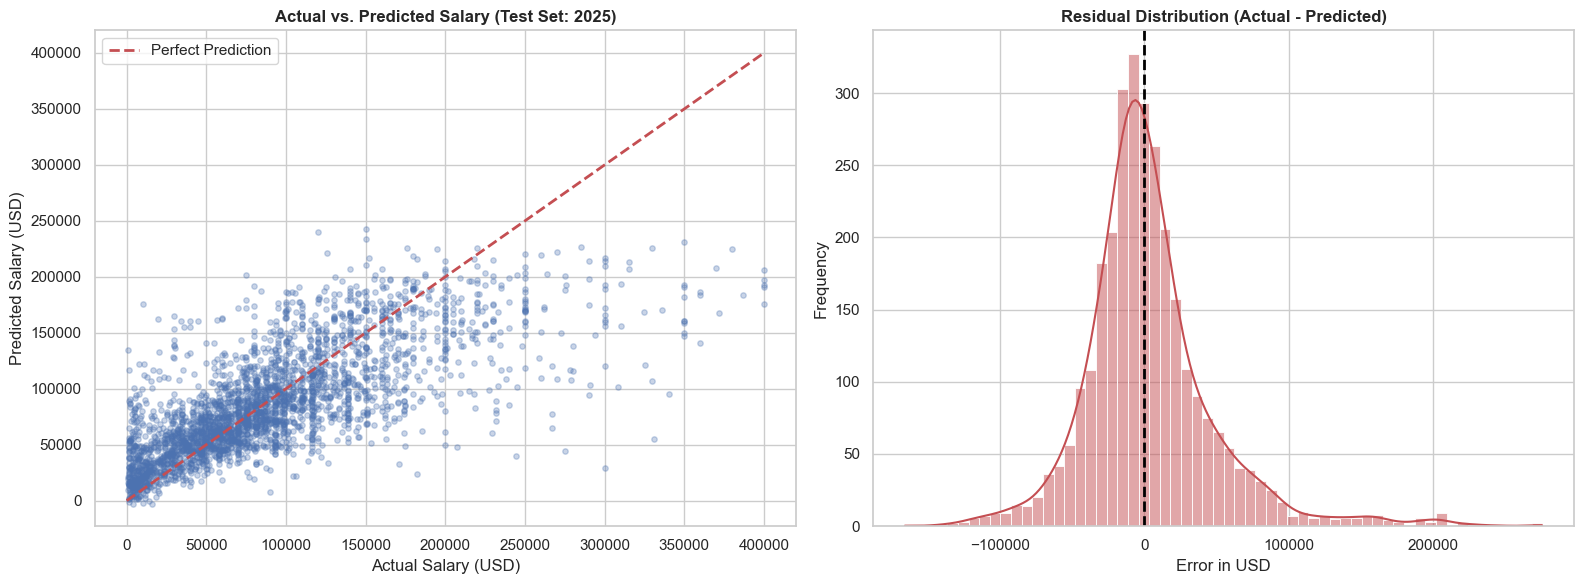

In [7]:
if os.path.exists(model_path):
    # Subsample for cleaner plotting
    plot_size = min(3000, len(y_test))
    np.random.seed(42)
    idx = np.random.choice(len(y_test), size=plot_size, replace=False)
    
    y_test_sub = y_test.iloc[idx].values
    y_pred_sub = y_pred[idx]
    residuals = y_test_sub - y_pred_sub
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Actual vs Predicted Plot
    axes[0].scatter(y_test_sub, y_pred_sub, alpha=0.3, color="#4C72B0", s=15)
    axes[0].plot([0, 400000], [0, 400000], 'r--', lw=2, label="Perfect Prediction")
    axes[0].set_title("Actual vs. Predicted Salary (Test Set: 2025)", fontweight='bold')
    axes[0].set_xlabel("Actual Salary (USD)")
    axes[0].set_ylabel("Predicted Salary (USD)")
    axes[0].legend()
    
    # 2. Residuals Distribution
    sns.histplot(residuals, bins=60, kde=True, ax=axes[1], color="#C44E52")
    axes[1].axvline(0, color='black', linestyle='--', lw=2)
    axes[1].set_title("Residual Distribution (Actual - Predicted)", fontweight='bold')
    axes[1].set_xlabel("Error in USD")
    axes[1].set_ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()